In [1]:
import pandas as pd
import os

filename = 'df_stage2_biso.pkl'
df_stage2 = pd.read_pickle(filename)
df_stage2[:3]

,Time,Eps_1,Eps_2,Eps_3,Time_Local
0,100.010,0.0075,0.004330,3.141510e-07,0.010
1,100.020,0.0075,0.004331,6.283020e-07,0.020
2,100.035,0.0075,0.004331,1.099528e-06,0.035


### 1. Численное дифференцирование методом сглаживающих сплайнов

Для обработки экспериментальных данных используется метод **сглаживающих сплайнов степени k** (Smoothing Cubic Splines). Мы ищем функцию $g(t)$, которая минимизирует функционал:

$$ p \sum_{i} w_i (y_i - g(t_i))^2 + (1-p) \int (g""(t))^2 dt $$

Где параметр сглаживания $s$ (связанный с $p$) определяет баланс между точностью приближения к исходным точкам и гладкостью кривой.

**Алгоритм подбора гиперпараметров $(s, k)$:**

Для выбора оптимальной степени полинома $k$ и параметра сглаживания $s$ применяется метод **поиска на сетке (Grid Search)** с валидацией по эталонному аналитическому решению.

Калибровка производится на компоненте $\ni_3$ (сдвиговая деформация), так как для неё физика процесса в ANSYS (сжимаемый материал) совпадает с аналитической кинематической моделью (нет влияния изменения объема).

Минимизируется взвешенная функция потерь, учитывающая точность первой, второй и третьей производных:

$$ Score(s, k) = w_1 \cdot \text{MSE}(\dot{\ni}_3^{num}, \dot{\ni}_3^{ana}) + w_2 \cdot \text{MSE}(\ddot{\ni}_3^{num}, \ddot{\ni}_3^{ana}) + w_3 \cdot \text{MSE}(\dddot{\ni}_3^{num}, \dddot{\ni}_3^{ana}) $$

где:
*   $\text{MSE}$ — нормированная среднеквадратичная ошибка;
*   $w_i$ — весовые коэффициенты (выбираются $w_3 \gg w_1$, чтобы обеспечить гладкость старших производных).

Параметры $(s, k)$, обеспечивающие минимум ошибки для $\ni_3$, затем применяются для дифференцирования остальных компонент вектора ($\ni_1, \ni_2$).

In [2]:
import numpy as np
from core.derivatives.spline import find_optimal_spline_params_mse
from core.derivatives.analytical import AnalyticalDerivatives


a_path = r"a.txt"
with open(a_path, "r") as f:
        a = float(f.read().strip())

c_path = r"c.txt"
with open(c_path, "r") as f:
        c = float(f.read().strip())

n_turns_path = r"n_turns.txt"
with open(n_turns_path, "r") as f:
        n_turns = float(f.read().strip())

step_n2_path = r"steps_n2.txt"
with open(step_n2_path, "r") as f:
        steps_n2 = float(f.read().strip())

nu_path = r"nu.txt"
with open(nu_path, "r") as f:
        nu = float(f.read().strip())

analytical = AnalyticalDerivatives(
    c=c, 
    a=a, 
    n_turns=n_turns, 
    duration=steps_n2,
    nu=nu
)


s_grid = np.logspace(-15, -5, 100) # От 1e-15 до 1e-5
k_grid = [3, 4, 5]           

best_s, best_k, res_df = find_optimal_spline_params_mse(
    df_stage2, 
    col_name="Eps_3", 
    time_col="Time_Local",
    analytic_obj=analytical,
    comp_idx=2,
    s_range=s_grid,
    k_range=k_grid
)

(best_s, best_k)

(np.float64(2.7185882427329403e-12), 5)

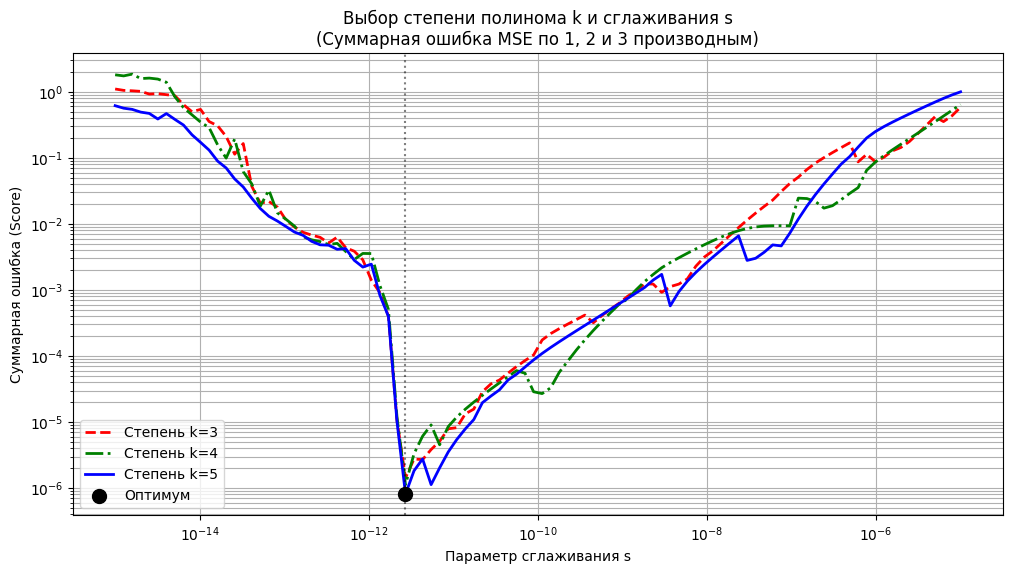

In [3]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

colors = {3: "red", 4: "green", 5: "blue"}
styles = {3: "--", 4: "-.", 5: "-"}

for k in k_grid:
    subset = res_df[res_df["k"] == k]
    plt.loglog(subset["s"], subset["score"], 
               color=colors[k], linestyle=styles[k], linewidth=2, 
               label=f"Степень k={k}")

# Отмечаем оптимум
plt.axvline(best_s, color="k", linestyle=":", alpha=0.5)
plt.scatter([best_s], [res_df["score"].min()], color="black", s=100, zorder=5, label="Оптимум")

plt.title("Выбор степени полинома k и сглаживания s\n(Суммарная ошибка MSE по 1, 2 и 3 производным)")
plt.xlabel("Параметр сглаживания s")
plt.ylabel("Суммарная ошибка (Score)")
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

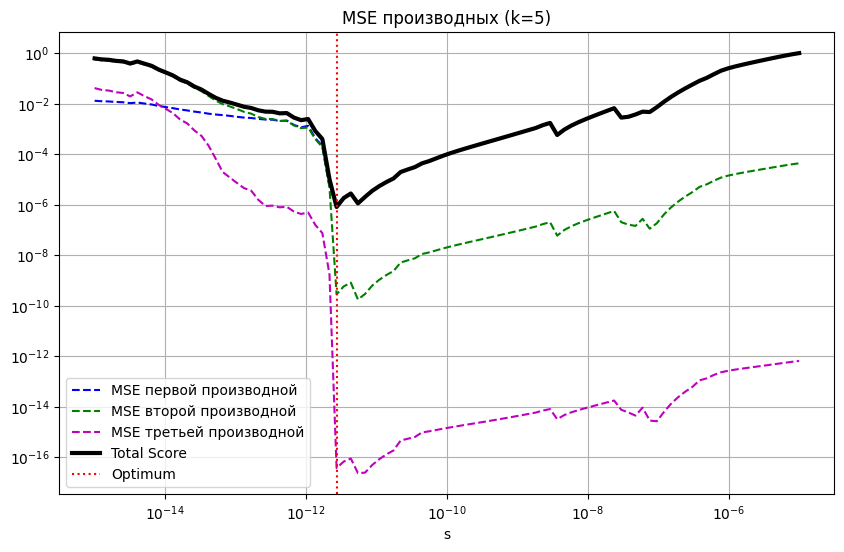

In [4]:
plt.figure(figsize=(10, 6))
subset = res_df[res_df['k'] == best_k]

plt.loglog(subset['s'], subset['mse1_norm'], 'b--', label='MSE первой производной')
plt.loglog(subset['s'], subset['mse2_norm'], 'g--', label='MSE второй производной')
plt.loglog(subset['s'], subset['mse3_norm'], 'm--', label='MSE третьей производной')
plt.loglog(subset['s'], subset['score'], 'k-', lw=3, label='Total Score')

plt.axvline(best_s, color='r', linestyle=':', label='Optimum')
plt.title(f'MSE производных (k={best_k})')
plt.xlabel('s')
plt.legend()
plt.grid(True)
plt.show()

### 2. Адаптивный подбор параметров сглаживания (Unsupervised Tuning)

При обработке реальных экспериментальных данных аналитическое решение ("Ground Truth") неизвестно. Следовательно, мы не можем вычислять ошибку производных напрямую.

В этом случае применяется эвристический подход к регуляризации. Задача сводится к поиску баланса между двумя конфликтующими целями:
1.  **Точность аппроксимации (Fidelity):** Сплайн должен проходить максимально близко к исходным точкам эксперимента.
2.  **Гладкость кривой (Regularity):** Производные сплайна (особенно высшие, используемые для расчета кручения) не должны содержать нефизичных осцилляций ("шума").

**Целевой функционал:**
Мы минимизируем комбинированную функцию потерь $J(s, k)$ на сетке параметров:

$$ J(s, k) = w_{fit} \cdot \overline{\text{MSE}}(y, S) + w_{smooth} \cdot \overline{\text{Roughness}}(\dddot{S}) $$

где:
*   $S(t)$ — построенный сплайн.
*   $\overline{\text{MSE}}(y, S)$ — нормированная среднеквадратичная ошибка отклонения сплайна от исходных точек.
*   $\overline{\text{Roughness}}(\dddot{S})$ — нормированная метрика "шероховатости" (Total Variation) третьей производной (рывка):
    $$ \text{Roughness} = \sum_{i} | \dddot{S}_{i+1} - \dddot{S}_i | $$

**Интерпретация:**
*   При малых $s$ ошибка аппроксимации минимальна, но "шероховатость" производных огромна (сплайн описывает шум).
*   При больших $s$ производные гладкие, но растет ошибка аппроксимации (сплайн "уходит" от экспериментальных точек).
*   Оптимум находится в точке минимума функционала $J$, что соответствует перегибу на L-кривой (L-curve criterion).

In [5]:
from core.derivatives.spline import find_optimal_spline_params_rough


s_grid = np.logspace(-15, -5, 100) # От 1e-15 до 1e-5
k_grid = [3, 4, 5]  
# weights_exp = (1.0, 0.0, 0.0, 0.5) 

best_s, best_k, res_exp_df = find_optimal_spline_params_rough(
    df_stage2, 
    col_name='Eps_3', 
    time_col='Time_Local',
    s_range=s_grid,
    k_range=k_grid,
    # weights=weights_exp
)

(best_s, best_k)

(np.float64(2.7185882427329403e-12), 4)

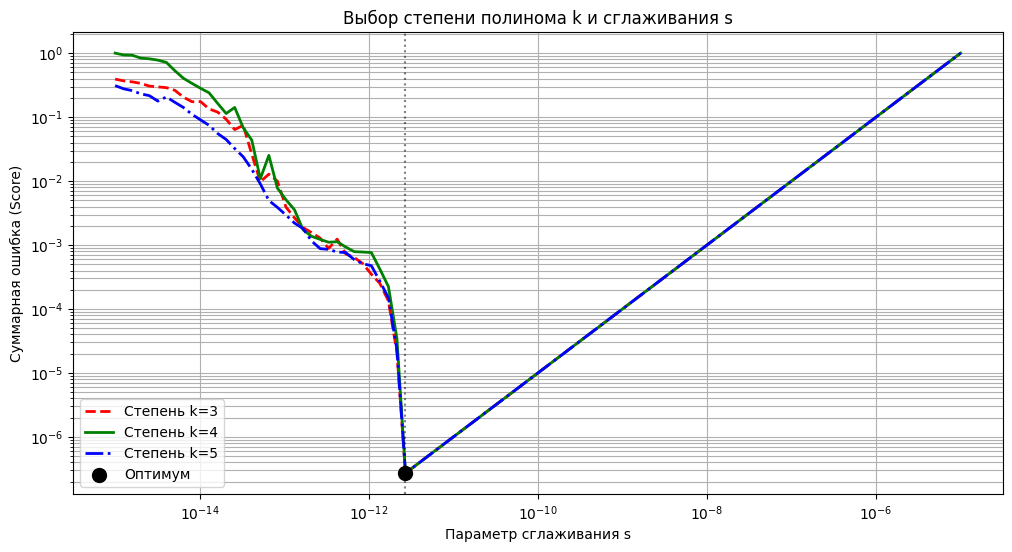

In [6]:
plt.figure(figsize=(12, 6))

colors = {3: "red", 4: "green", 5: "blue"}
styles = {3: "--", 4: "-", 5: "-."}

for k in k_grid:
    subset = res_exp_df[res_exp_df["k"] == k]
    plt.loglog(subset["s"], subset["score"], 
               color=colors[k], linestyle=styles[k], linewidth=2, 
               label=f"Степень k={k}")

# Отмечаем оптимум
plt.axvline(best_s, color="k", linestyle=":", alpha=0.5)
plt.scatter([best_s], [res_exp_df["score"].min()], color="black", s=100, zorder=5, label="Оптимум")

plt.title("Выбор степени полинома k и сглаживания s")
plt.xlabel("Параметр сглаживания s")
plt.ylabel("Суммарная ошибка (Score)")
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

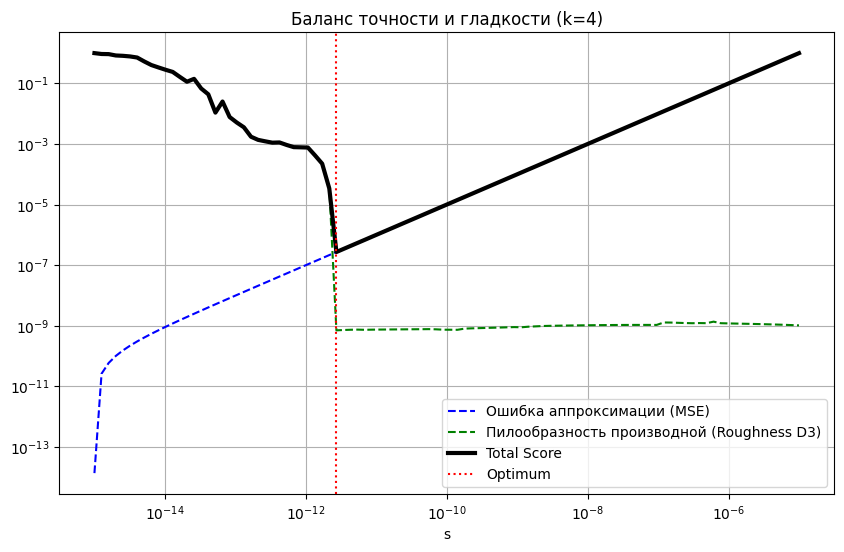

In [7]:
plt.figure(figsize=(10, 6))
subset = res_exp_df[res_exp_df['k'] == best_k]

plt.loglog(subset['s'], subset['mse_func_norm'], 'b--', label='Ошибка аппроксимации (MSE)')
plt.loglog(subset['s'], subset['rough_d3_norm'], 'g--', label='Пилообразность производной (Roughness D3)')
plt.loglog(subset['s'], subset['score'], 'k-', lw=3, label='Total Score')

plt.axvline(best_s, color='r', linestyle=':', label='Optimum')
plt.title(f'Баланс точности и гладкости (k={best_k})')
plt.xlabel('s')
plt.legend()
plt.grid(True)
plt.show()

### 3. Исследование устойчивости метода к плотности данных (Sensitivity Analysis)

Поскольку численное моделировани может содержать сколь угодно большое количество точек, необходимо изучить применимость и устойчивость предложенного эвристического функционала $J(s, k)$ при разном объеме выборки.

**Методика исследования:**
Проводится серия численных экспериментов на "идеальном" наборе данных ANSYS, подвергнутом процедуре искусственного прореживания (децимации). Количество точек $N$ варьируется в логарифмическом масштабе от 30 до полного объема выборки.

Для каждого значения $N$ независимо решается задача оптимизации без учителя:
$$ (s_{opt}, k_{opt}) = \arg \min_{s, k} J(s, k) $$

**Анализируемые зависимости:**
1.  **$s_{opt}(N)$:** Характеризует адаптацию параметра сглаживания к объему данных. Теоретически ожидается рост $s$ при уменьшении $N$ (компенсация недостатка информации усилением регуляризации).
2.  **$k_{opt}(N)$:** Показывает, позволяет ли плотность сетки использовать сплайны высокой степени ($k=5$). При критически малом $N$ возможен вынужденный переход к более простым моделям ($k=3$).
3.  **Score($N$):** Минимальное значение функционала, характеризующее достижимый баланс качества.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. СБОР ДАННЫХ ---
total_points = len(df_stage2)
# Сетка количества точек
target_counts_rough = np.array([30, 40, 50, 60, 80, 100, 200, 500, 1000, 2000, 5000, total_points])
target_counts_rough = np.unique(target_counts_rough[target_counts_rough <= total_points])

results_rough_study = []
# Широкий диапазон для s
s_grid_rough = np.logspace(-16, -2, 100) 

print(f"Исследование зависимости s, k и Score от N...")

for n_target in target_counts_rough:
    # Прореживание
    step = int(total_points / n_target)
    if step < 1: step = 1
    df_subset = df_stage2.iloc[::step].copy()
    real_n = len(df_subset)
    
    # Поиск оптимума
    best_s, best_k, res_df = find_optimal_spline_params_rough(
        df_subset, 
        col_name='Eps_3', 
        time_col='Time_Local',
        s_range=s_grid_rough,
        k_range=[3, 4, 5],
        weights=(1.0, 0.0, 0.0, 1.0) 
    )
    
    # Берем минимальный Score
    min_score = res_df['score'].min()
    
    results_rough_study.append({
        'N': real_n,
        'best_s': best_s,
        'best_k': best_k,   # <--- Сохраняем степень полинома
        'min_score': min_score
    })
    print(f"N={real_n:5d} | k={best_k} | s={best_s:.2e} | Score={min_score:.2e}")

df_study_rough = pd.DataFrame(results_rough_study)

# --- 2. ВИЗУАЛИЗАЦИЯ ---
# Делаем фигуру шире, чтобы поместилось 3 графика
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# === График 1: Оптимальное s(N) ===
ax1.loglog(df_study_rough['N'], df_study_rough['best_s'], 'mo-', lw=2, markersize=8, label='Optimal s')
ax1.set_title('Зависимость параметра сглаживания s от N')
ax1.set_xlabel('Количество точек N')
ax1.set_ylabel('Optimal s')
ax1.grid(True, which="both", ls="-")
ax1.legend()

# === График 2: Оптимальная степень k(N) ===
# Используем semilogx, так как k - линейная величина (3, 4, 5)
ax2.semilogx(df_study_rough['N'], df_study_rough['best_k'], 'rs-', lw=2, markersize=8, label='Optimal k')

ax2.set_title('Зависимость степени полинома k от N')
ax2.set_xlabel('Количество точек N')
ax2.set_ylabel('Degree k')
ax2.set_yticks([3, 4, 5]) # У нас только дискретные значения
ax2.grid(True, which="both", ls="-")
ax2.legend()

# === График 3: Minimum Score(N) ===
ax3.loglog(df_study_rough['N'], df_study_rough['min_score'], 'bD-', lw=2, markersize=8, label='Min Total Score')
ax3.set_title('Минимальное значение функционала (Score) от N')
ax3.set_xlabel('Количество точек N')
ax3.set_ylabel('Score')
ax3.grid(True, which="both", ls="-")

# Отметим область реального эксперимента
ax3.axvline(x=60, color='r', linestyle=':', label='Experiment (~60)')
ax3.legend()

plt.tight_layout()
plt.show()